Dataset Shape: (1143, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data Types and Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               11

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000



Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing Value Percentage:
fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
Id                      0.0
dtype: float64

Duplicate Rows: 0

Unique Values:
quality                    6
free sulfur dioxide       53
alcohol                   61
citric acid               77
residual sugar            80
pH                        87
sulphates        

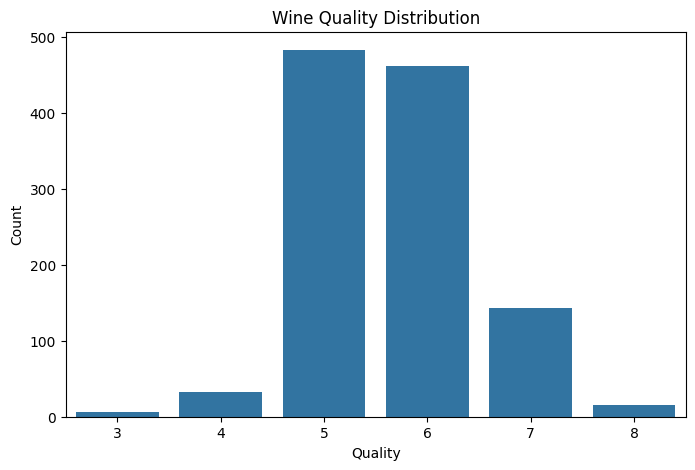

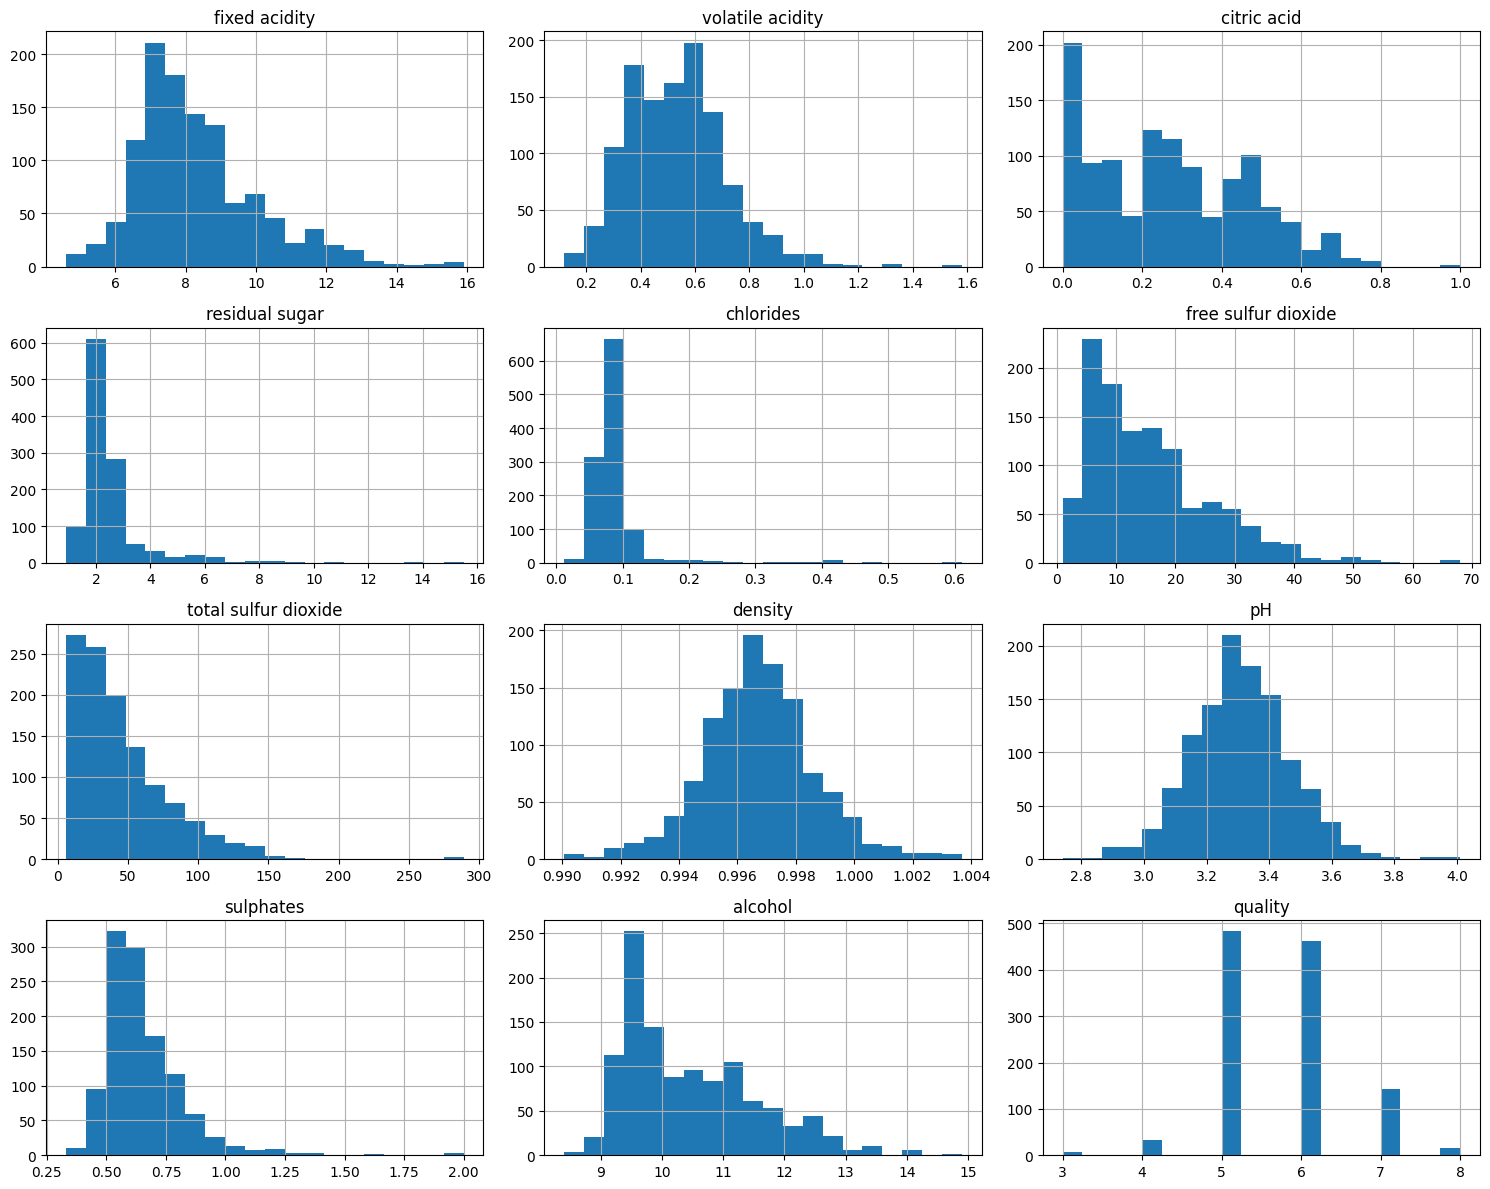

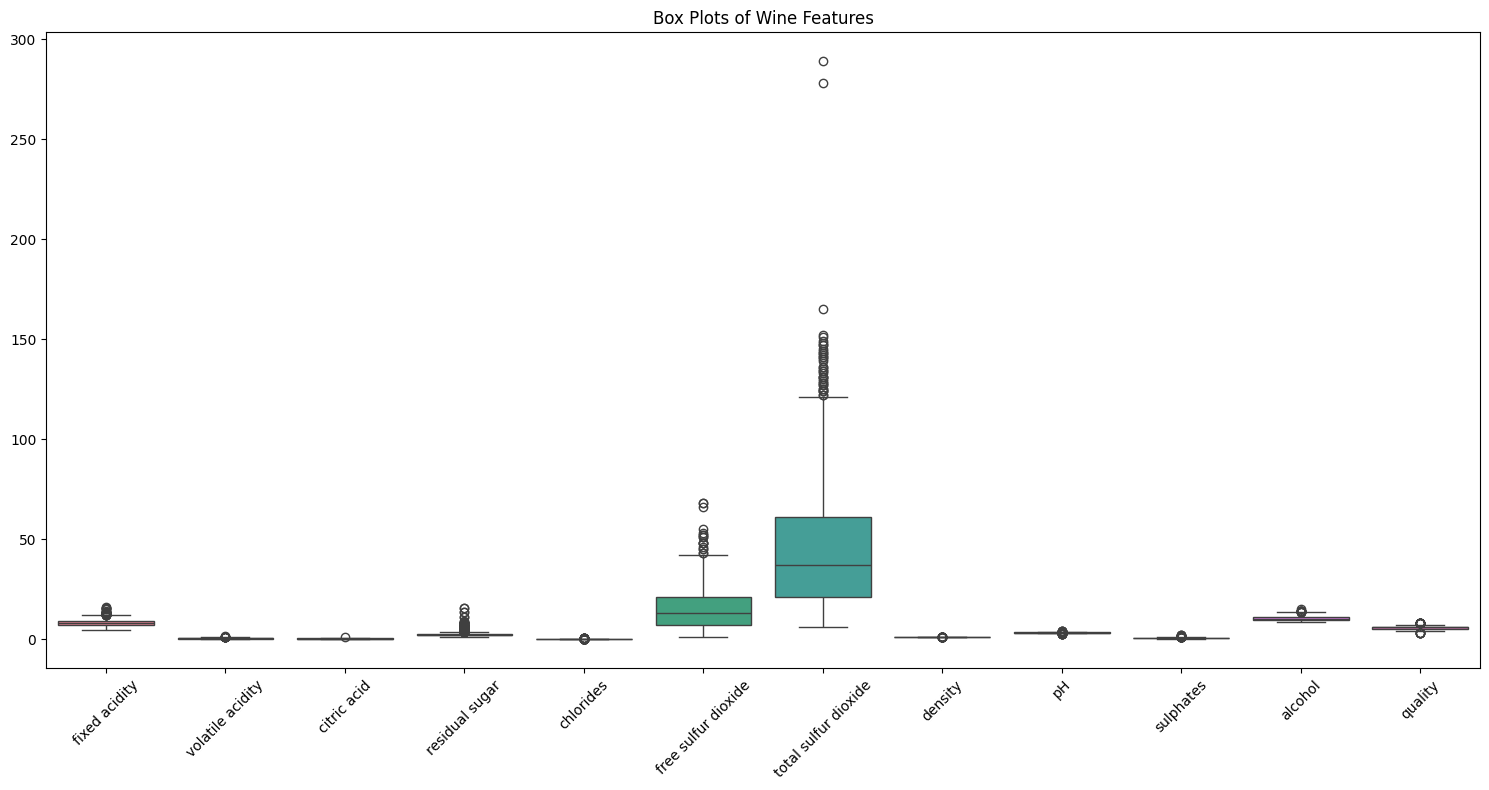

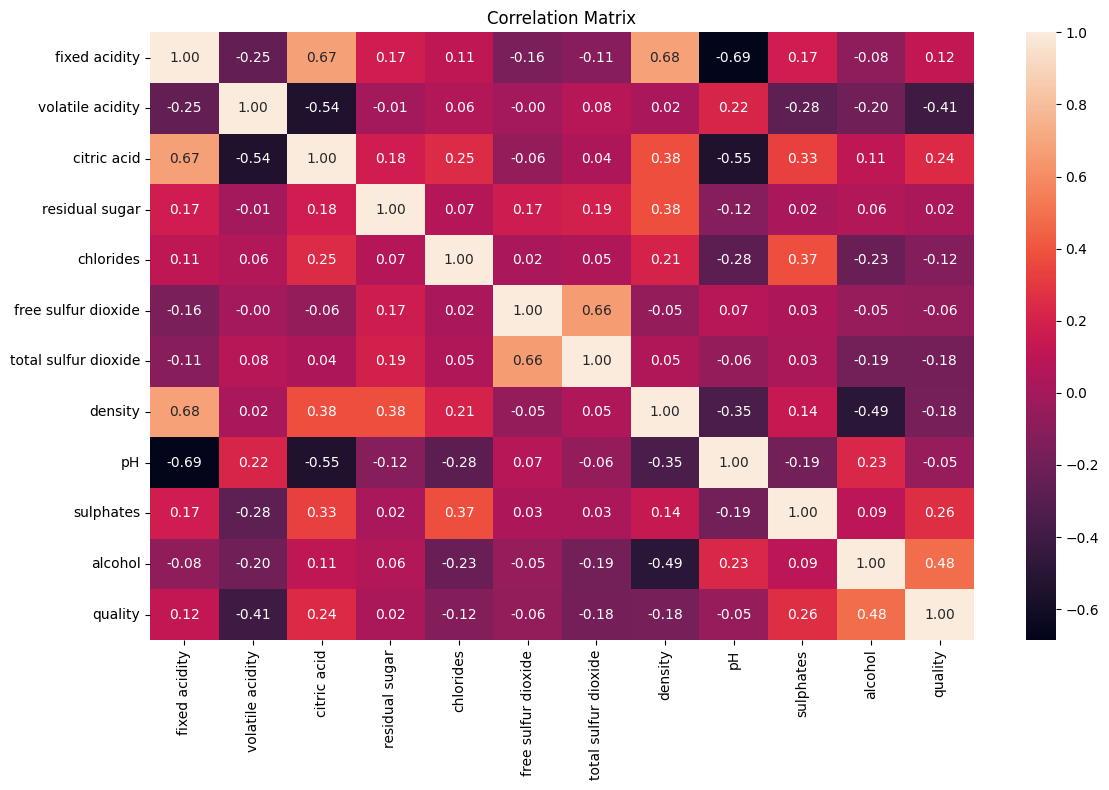


Strongest Correlations:
fixed acidity        pH                     -0.685163
                     density                 0.681501
                     citric acid             0.673157
free sulfur dioxide  total sulfur dioxide    0.661093
citric acid          pH                     -0.546339
volatile acidity     citric acid            -0.544187
density              alcohol                -0.494727
alcohol              quality                 0.484866
volatile acidity     quality                -0.407394
residual sugar       density                 0.380147
dtype: float64


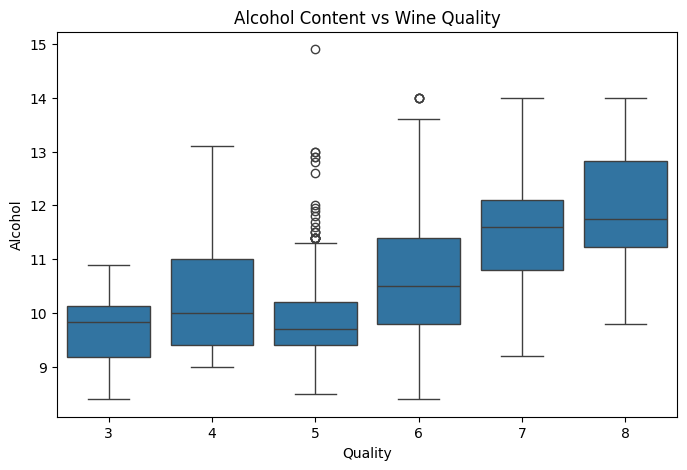

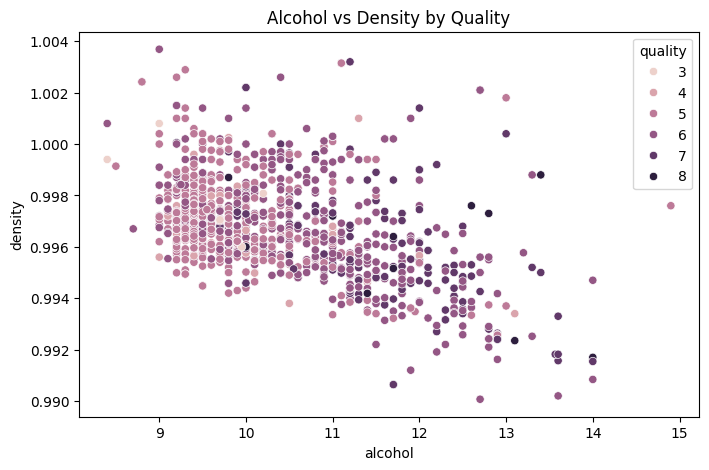

In [2]:
# ============================================================
# 01 - Exploratory Data Analysis
# Wine Quality Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/WineQT.csv")

# ============================================================
# 1. Dataset Overview
# ============================================================

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types and Structure:")
df.info()

print("\nStatistical Summary:")
display(df.describe().T)

# ============================================================
# 2. Data Quality
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique().sort_values())

# ============================================================
# 3. Quality Distribution
# ============================================================

print("\nQuality Distribution:")
print(df["quality"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="quality")
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

# ============================================================
# 4. Feature Distributions
# ============================================================

df.drop(columns=["Id"]).hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Box Plots
# ============================================================

plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop(columns=["Id"]))
plt.xticks(rotation=45)
plt.title("Box Plots of Wine Features")
plt.tight_layout()
plt.show()

# ============================================================
# 6. Correlation Analysis
# ============================================================

correlation = df.drop(columns=["Id"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Find strongest correlations
corr_pairs = (
    correlation
    .where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("\nStrongest Correlations:")
print(corr_pairs.head(10))

# ============================================================
# 7. Feature vs Quality
# ============================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="quality", y="alcohol")
plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="alcohol",
    y="density",
    hue="quality"
)
plt.title("Alcohol vs Density by Quality")
plt.show()